<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 162.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 174.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 141.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 154.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
# 1. Clean and calculate percentage distribution
industry_counts = df["Industry"].value_counts(dropna=True)
industry_pct = (df["Industry"].value_counts(normalize=True, dropna=True) * 100).reset_index()
industry_pct.columns = ["Industry", "Percentage"]

print("--- Respondent Distribution Across Industry Sectors (%) ---")
display(industry_pct.round(2))

--- Respondent Distribution Across Industry Sectors (%) ---

,Industry,Percentage
0,Software Development,41.30
1,Other:,10.66
2,Fintech,5.69
3,"Internet, Telecomm or Information Services",5.64
4,Banking/Financial Services,4.75
5,Healthcare,4.43
6,Manufacturing,4.38
7,Retail and Consumer Services,4.38
8,Government,3.33
9,Media & Advertising Services,3.10


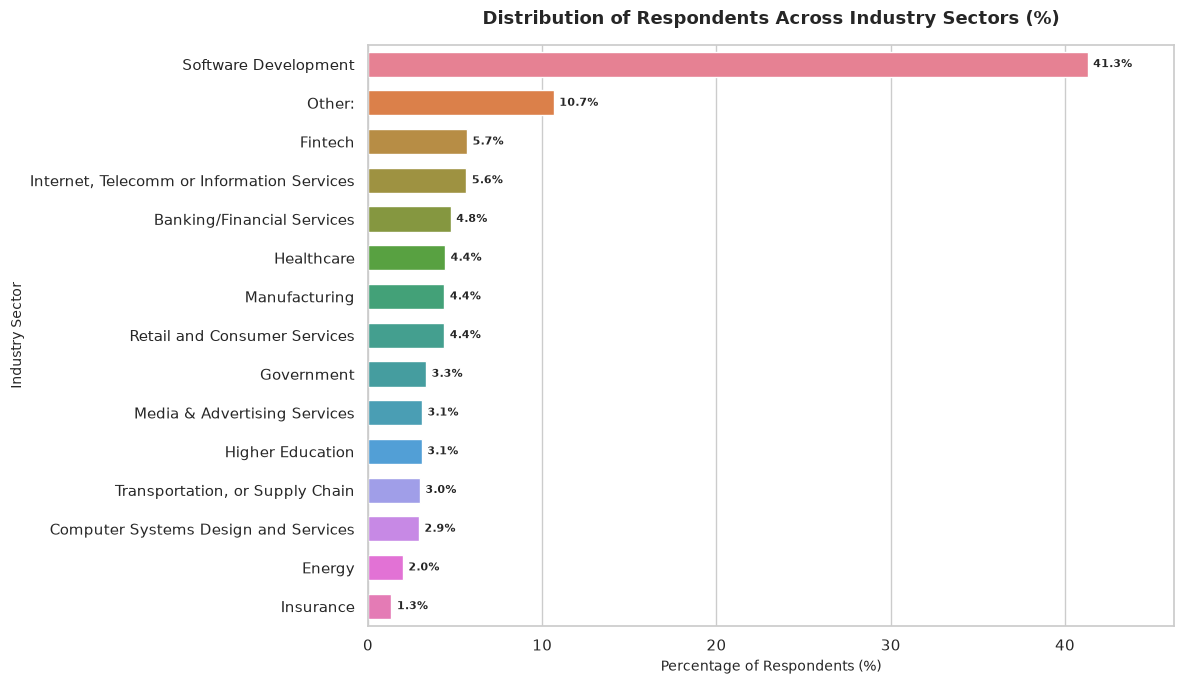

In [6]:
# Set figure styling
sns.set_theme(style="whitegrid", font="sans-serif")
plt.figure(figsize=(12, 7))

# Plot horizontal bar chart
ax = sns.barplot(
    data=industry_pct,
    y="Industry",
    x="Percentage",
    hue="Industry",
    width=0.65
)

plt.title(
    "Distribution of Respondents Across Industry Sectors (%)",
    fontsize=13,
    fontweight="bold",
    pad=15
)
plt.xlabel("Percentage of Respondents (%)", fontsize=10)
plt.ylabel("Industry Sector", fontsize=10)

# Annotate percentage values on top of bars
for p in ax.patches:
    width_val = p.get_width()
    if width_val > 0.5:
        ax.annotate(
            f"{width_val:.1f}%",
            (width_val, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8,
            fontweight="bold",
            xytext=(4, 0),
            textcoords="offset points"
        )

plt.xlim(0, industry_pct["Percentage"].max() * 1.12)
plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [8]:
# Filter out missing compensation values for valid statistical calculations
comp_data = df["ConvertedCompYearly"].dropna()

# Calculate Basic Summary Statistics
comp_mean = comp_data.mean()
comp_median = comp_data.median()
comp_std = comp_data.std()
comp_min = comp_data.min()
comp_max = comp_data.max()

print("=== Summary Statistics for ConvertedCompYearly ===")
print(f"Sample Count (n):    {len(comp_data):,}")
print(f"Mean Compensation:   ${comp_mean:,.2f}")
print(f"Median Compensation: ${comp_median:,.2f}")
print(f"Standard Deviation:  ${comp_std:,.2f}")
print(f"Min Compensation:    ${comp_min:,.2f}")
print(f"Max Compensation:    ${comp_max:,.2f}\n")

# Detect Outliers: 3 Standard Deviations Above Mean
std_threshold = comp_mean + (3 * comp_std)
std_outliers = comp_data[comp_data > std_threshold]

print("=== Outlier Threshold: 3 Standard Deviations Above Mean ===")
print(f"3-Std Threshold Value: ${std_threshold:,.2f}")
print(f"Number of Outliers:    {len(std_outliers):,} ({len(std_outliers)/len(comp_data)*100:.2f}%)")
if len(std_outliers) > 0:
    print(f"Outlier Range:         ${std_outliers.min():,.2f} to ${std_outliers.max():,.2f}\n")

=== Summary Statistics for ConvertedCompYearly ===
Sample Count (n):    23,435
Mean Compensation:   $86,155.29
Median Compensation: $65,000.00
Standard Deviation:  $186,756.97
Min Compensation:    $1.00
Max Compensation:    $16,256,603.00

=== Outlier Threshold: 3 Standard Deviations Above Mean ===
3-Std Threshold Value: $646,426.21
Number of Outliers:    89 (0.38%)
Outlier Range:         $650,000.00 to $16,256,603.00


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [9]:

# Alternative Robust Detection: IQR Method (1.5 x IQR)
Q1 = comp_data.quantile(0.25)
Q3 = comp_data.quantile(0.75)
IQR = Q3 - Q1
iqr_threshold = Q3 + (1.5 * IQR)
iqr_outliers = comp_data[comp_data > iqr_threshold]

print("=== Outlier Threshold: IQR Method (Q3 + 1.5 * IQR) ===")
print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR Threshold Value:  ${iqr_threshold:,.2f}")
print(f"Number of Outliers:   {len(iqr_outliers):,} ({len(iqr_outliers)/len(comp_data)*100:.2f}%)")

=== Outlier Threshold: IQR Method (Q3 + 1.5 * IQR) ===
Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR Threshold Value:  $220,860.75
Number of Outliers:   978 (4.17%)

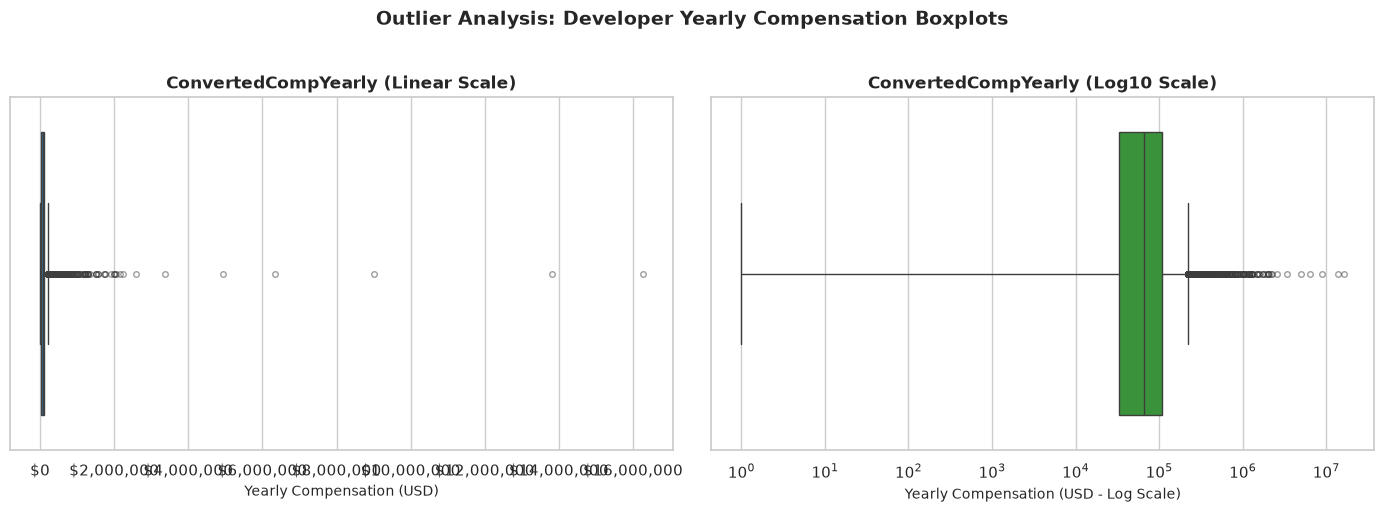

In [11]:
# Filter out non-positive/missing compensation entries for clean plotting
comp_valid = df[df["ConvertedCompYearly"] > 0]["ConvertedCompYearly"].dropna()

# Set up figure with two side-by-side subplots
sns.set_theme(style="whitegrid", font="sans-serif")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Standard Scale Boxplot
sns.boxplot(
    x=comp_valid,
    ax=ax1,
    color="#1f77b4",
    flierprops=dict(marker="o", color="#d62728", alpha=0.5, markersize=4),
)

ax1.set_title(
    "ConvertedCompYearly (Linear Scale)", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Yearly Compensation (USD)", fontsize=10)
# Format x-axis with dollar commas
ax1.xaxis.set_major_formatter("${x:,.0f}")

# Plot 2: Log10 Transformed Scale Boxplot
sns.boxplot(
    x=comp_valid,
    ax=ax2,
    color="#2ca02c",
    flierprops=dict(marker="o", color="#d62728", alpha=0.5, markersize=4),
)

ax2.set_xscale("log")  # Logarithmic scale highlights central distribution
ax2.set_title(
    "ConvertedCompYearly (Log10 Scale)", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Yearly Compensation (USD - Log Scale)", fontsize=10)

plt.suptitle(
    "Outlier Analysis: Developer Yearly Compensation Boxplots",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [12]:
# Ensure working data has valid numeric values for compensation
valid_comp_mask = df["ConvertedCompYearly"].notna() & (
    df["ConvertedCompYearly"] > 0
)

# Calculate Mean and Std on valid compensation records
mean_comp = df.loc[valid_comp_mask, "ConvertedCompYearly"].mean()
std_comp = df.loc[valid_comp_mask, "ConvertedCompYearly"].std()

# Define upper threshold (3 standard deviations above mean)
upper_threshold = mean_comp + (3 * std_comp)

# Filter out rows exceeding 3 Std Dev 
outlier_mask = df["ConvertedCompYearly"] > upper_threshold

# Create new filtered DataFrame
df_no_outliers = df[~outlier_mask].copy()

# Size Validation & Audit Report
original_rows = len(df)
filtered_rows = len(df_no_outliers)
removed_rows = outlier_mask.sum()
retention_pct = (filtered_rows / original_rows) * 100

print("=== DataFrame Outlier Truncation Validation ===")
print(f"Upper Threshold (3 Std Dev): ${upper_threshold:,.2f}")
print(f"Original DataFrame Rows:    {original_rows:,}")
print(f"Rows Removed (Outliers):    {removed_rows:,}")
print(f"New DataFrame Rows:         {filtered_rows:,}")
print(f"Sample Retention Rate:      {retention_pct:.2f}%")

=== DataFrame Outlier Truncation Validation ===
Upper Threshold (3 Std Dev): $646,426.21
Original DataFrame Rows:    65,437
Rows Removed (Outliers):    89
New DataFrame Rows:         65,348
Sample Retention Rate:      99.86%

In [18]:
# Calculate 3.0x IQR threshold
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1
upper_bound_iqr = Q3 + (3.0 * IQR)
# Keep rows <= upper_bound OR where salary is NaN
valid_mask = (df["ConvertedCompYearly"] <= upper_bound_iqr) | df["ConvertedCompYearly"].isna()
df_no_iqr_outliers = df[valid_mask].copy()
# Size Validation & Audit Report
original_rows = len(df)
filtered_rows = len(df_no_iqr_outliers)
retention_pct = (filtered_rows / original_rows) * 100
removed_rows - original_rows - filtered_rows

print("=== DataFrame Outlier Truncation Validation ===")
print(f"Upper Threshold (3 IQR): ${upper_bound_iqr:,.2f}")
print(f"Original DataFrame Rows:    {original_rows:,}")
print(f"Rows Removed (Outliers):    {removed_rows:,}")
print(f"New DataFrame Rows:         {filtered_rows:,}")
print(f"Sample Retention Rate:      {retention_pct:.2f}%")

=== DataFrame Outlier Truncation Validation ===
Upper Threshold (3 IQR): $333,750.00
Original DataFrame Rows:    65,437
Rows Removed (Outliers):    89
New DataFrame Rows:         65,121
Sample Retention Rate:      99.52%

In [ ]:
# Save final DataFrame
df_no_iqr_outliers.to_csv("survey_results_cleaned_comp_outliers.csv", index=False)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [19]:
# Map ordinal Age range strings to representative midpoint numeric values
age_map = {
    "Under 18 years old": 15.0,
    "18-24 years old": 21.0,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 70.0,
    "Prefer not to say": np.nan,
}

df["Age_Numeric"] = df["Age"].map(age_map)

# Select key numeric features for correlation analysis
numeric_cols = [
    "Age_Numeric",
    "YearsCodePro_Numeric",
    "ConvertedCompYearly",
    "JobSat",
    "WorkExp",
]

# Keep only existing numeric columns in df
available_cols = [c for c in numeric_cols if c in df.columns]

# Compute Pearson correlation matrix across non-null pairs
corr_matrix = df[available_cols].corr(method="pearson")

print("=== Pearson Correlation Matrix ===")
display(corr_matrix.round(3))

=== Pearson Correlation Matrix ===

,Age_Numeric,ConvertedCompYearly,JobSat,WorkExp
Age_Numeric,1.000,0.122,0.070,0.850
ConvertedCompYearly,0.122,1.000,0.048,0.154
JobSat,0.070,0.048,1.000,0.097
WorkExp,0.850,0.154,0.097,1.000


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
